In [1]:
!pip install imbalanced-learn scikit-learn torch -q

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


from collections import Counter
import warnings
warnings.filterwarnings("ignore")

import os

In [4]:
data_dir = '/content/drive/MyDrive/GEE_LST_Exports'
train_df = pd.read_csv(f'{data_dir}/Kozan_Fire_Risk_Dataset.csv')

In [5]:
train_df.columns

Index(['system:index', 'BSI', 'EVI', 'LST_C', 'MODIS_LST', 'NBR', 'NDVI',
       'NDWI', 'SAVI', 'aspect', 'elevation', 'fire_label', 'month', 'slope',
       '.geo'],
      dtype='object')

In [6]:
train_df.head()

,system:index,BSI,EVI,LST_C,MODIS_LST,NBR,NDVI,NDWI,SAVI,aspect,elevation,fire_label,month,slope,.geo
0,1_2020047_+23179+5857,0.000239,0.275958,33.281601,30.173379,0.247322,0.480017,-0.508013,0.278215,147.838350,64.0,1,2,0.205427,"{""type"":""MultiPoint"",""coordinates"":[]}"
1,1_2020150_+23186+5846,-0.066036,0.347327,31.054775,28.637498,0.347049,0.579226,-0.581892,0.347260,105.268719,51.0,1,5,1.210488,"{""type"":""MultiPoint"",""coordinates"":[]}"
2,1_2020163_+23163+5857,0.061784,0.244327,33.155318,30.986082,0.186898,0.383922,-0.436876,0.249948,137.752213,152.0,1,6,0.704750,"{""type"":""MultiPoint"",""coordinates"":[]}"
3,1_2020172_+23170+5850,0.045943,0.247367,34.196650,32.278210,0.209912,0.417190,-0.464131,0.254442,72.369590,133.0,1,6,0.574159,"{""type"":""MultiPoint"",""coordinates"":[]}"
4,1_2020177_+23186+5860,0.068906,0.235299,33.983681,31.188129,0.131512,0.348238,-0.405712,0.232834,162.552687,49.0,1,6,0.121527,"{""type"":""MultiPoint"",""coordinates"":[]}"


In [7]:
train_df.describe()

,BSI,EVI,LST_C,MODIS_LST,NBR,NDVI,NDWI,SAVI,aspect,elevation,fire_label,month,slope
count,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,607.000000,597.000000,607.000000,607.000000,607.000000,597.000000
mean,0.004151,0.260553,29.774902,26.919421,0.262588,0.456922,-0.483519,0.264815,178.977103,524.716639,0.217463,6.431631,4.939463
std,0.068979,0.050026,3.948902,3.862379,0.102455,0.094134,0.155154,0.045830,78.827424,472.795013,0.412860,1.253979,4.994244
min,-0.185202,0.071013,18.900485,16.985623,0.041569,0.215296,-0.645838,0.088429,2.078435,34.000000,0.000000,1.000000,0.028984
25%,-0.044085,0.229916,26.479809,23.871396,0.177084,0.384631,-0.539777,0.234949,125.469340,128.500000,0.000000,6.000000,0.906153
50%,0.013637,0.261520,30.138002,26.683728,0.245611,0.451120,-0.486675,0.265244,162.537170,393.000000,0.000000,6.000000,3.289445
75%,0.057191,0.292604,33.156161,30.633445,0.343807,0.525033,-0.438637,0.292908,245.745480,797.000000,0.000000,6.000000,7.763349
max,0.152825,0.424179,36.680558,33.718228,0.520666,0.673999,2.911438,0.418397,358.907200,2088.000000,1.000000,12.000000,22.822966


# Variable Description
  1. system:index : Automatically assigned row ID by GEE — not used in the model
  1. BSI: Bare Soil Index — high = less vegetation → higher fire risk
  2. EVI: Enhanced Vegetation Index — more sensitive than NDVI
  3. LST_C: Land Surface Temperature from Landsat (°C) — 30 m resolution
  4. MODIS_LST: Land Surface Temperature from MODIS (°C) — 1 km resolution
  5. NBR: Normalized Burn Ratio — decreases after fire
  6. NDVI: Normalized Difference Vegetation Index — high = dense vegetation, low = bare soil
  7. NDWI: Water / Moisture Index — low = dry area → higher fire risk
  8. SAVI: Soil Adjusted Vegetation Index — reduces soil effect, suitable for agricultural areas
  9. aspect: Aspect (degrees) — south-facing slopes tend to be drier
  10. elevation: Elevation (Elevation in meters) — derived from DEM
  11. fire_label: Target variable — 1 = fire present, 0 = no fire
  12. month: Month (1–12) — used for seasonality
  13. slope: Slope (degrees) — steeper slopes accelerate fire spread
  14. .geo: Coordinate information (empty) — not used in the model

In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 607 entries, 0 to 606
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   system:index  607 non-null    object 
 1   BSI           607 non-null    float64
 2   EVI           607 non-null    float64
 3   LST_C         607 non-null    float64
 4   MODIS_LST     607 non-null    float64
 5   NBR           607 non-null    float64
 6   NDVI          607 non-null    float64
 7   NDWI          607 non-null    float64
 8   SAVI          607 non-null    float64
 9   aspect        597 non-null    float64
 10  elevation     607 non-null    float64
 11  fire_label    607 non-null    int64  
 12  month         607 non-null    int64  
 13  slope         597 non-null    float64
 14  .geo          607 non-null    object 
dtypes: float64(11), int64(2), object(2)
memory usage: 71.3+ KB


# Univariate Variable Analysis
Categorical Variable: system:index, .geo

Numerical Variable: BSI, EVI, LST_C, MODIS_LST, NBR, NDVI, NDWI, SAVI, aspect, elevation, fire_label, month, slope

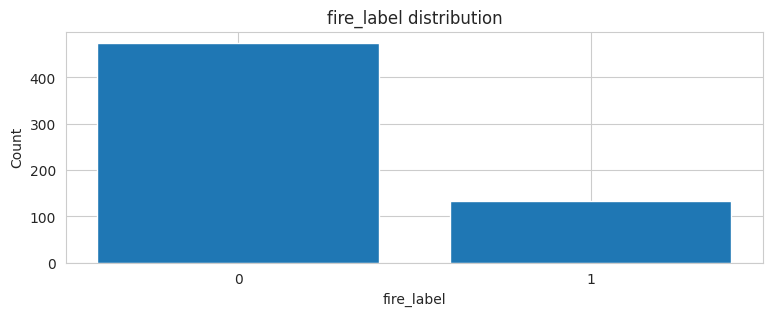

fire_label:
fire_label
0    475
1    132
Name: count, dtype: int64



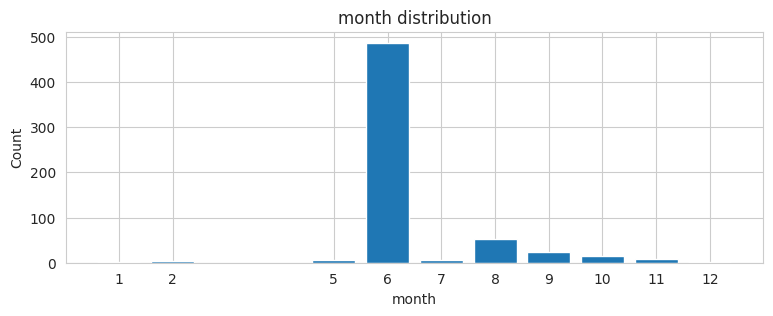

month:
month
6     487
8      53
9      24
10     15
11      8
5       7
7       5
2       4
1       2
12      2
Name: count, dtype: int64



In [9]:
# Categorical variable analysis with bar plot — fire_label and month
def plot_bar(variable):
    plt.figure(figsize=(9, 3))
    df_temp = train_df[variable].value_counts()
    plt.bar(df_temp.index, df_temp.values)
    plt.xlabel(variable)
    plt.ylabel("Count")
    plt.title(f"{variable} distribution")
    plt.xticks(df_temp.index)
    plt.show()
    print(f"{variable}:\n{df_temp}\n")

categorical_var = ["fire_label", "month"]
for c in categorical_var:
    plot_bar(c)

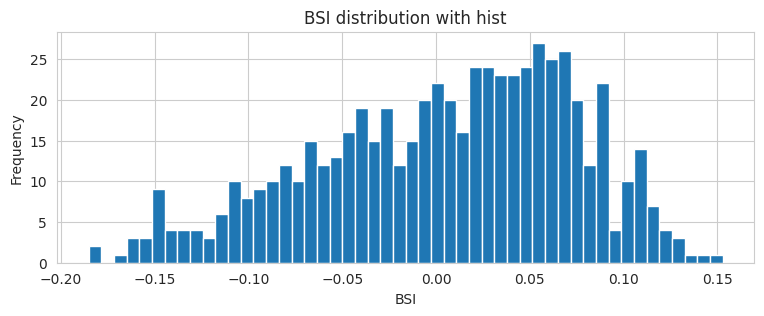

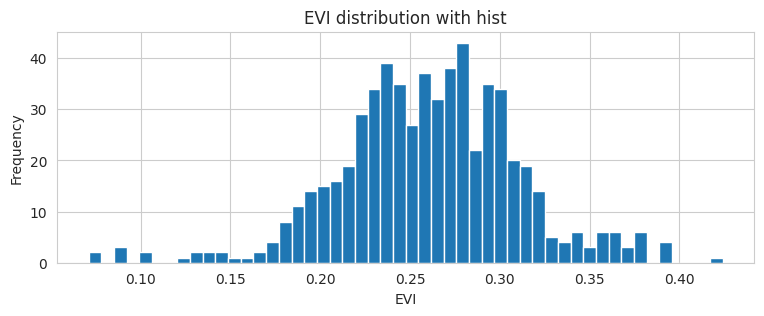

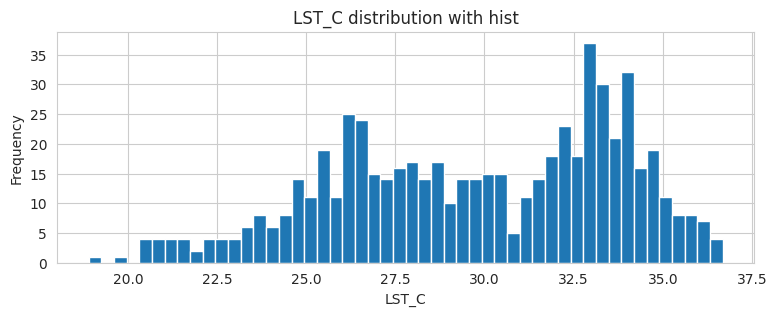

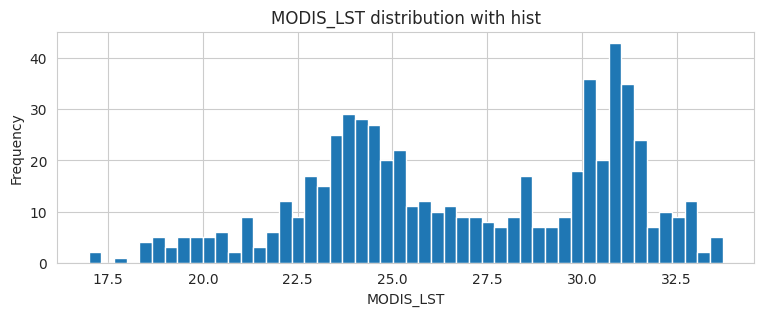

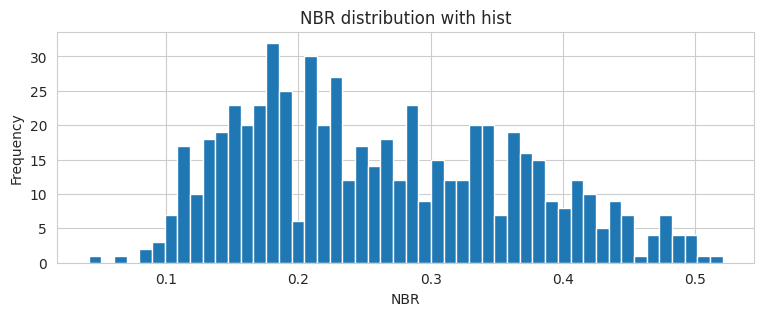

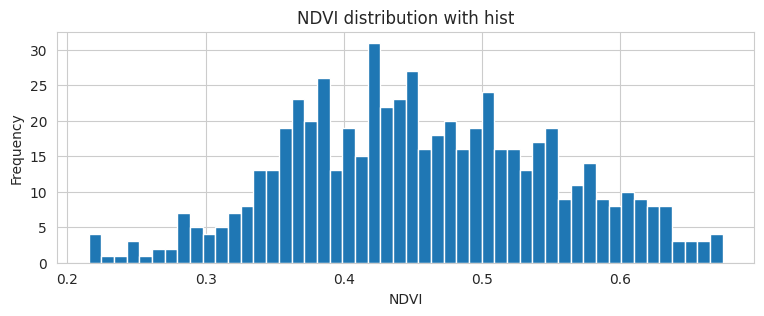

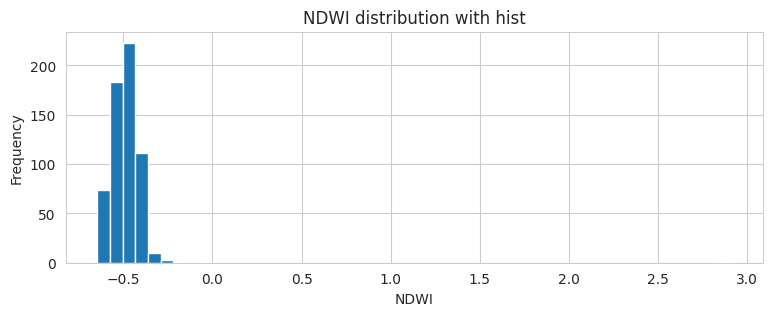

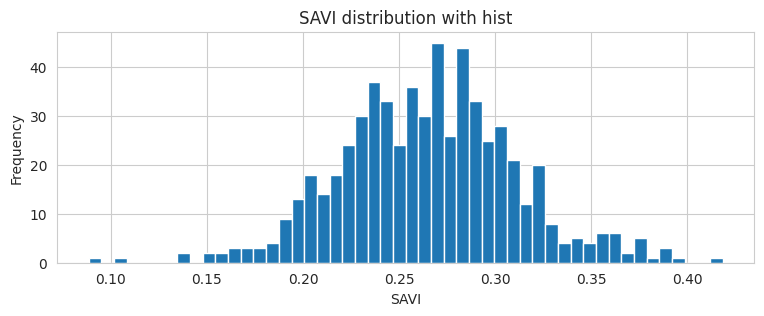

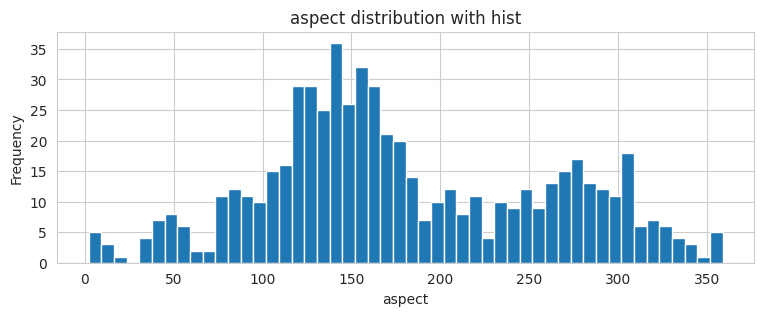

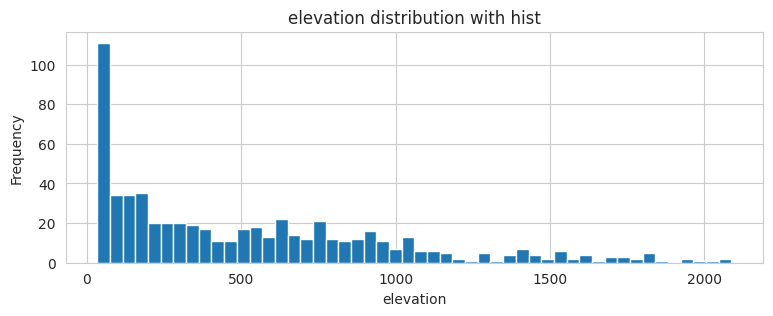

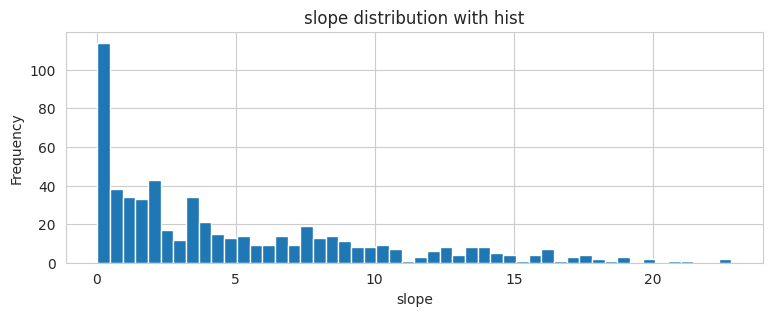

In [10]:
# Numerical variable analysis with histogram
def plot_hist(variable):
  plt.figure(figsize = (9,3))
  plt.hist(train_df[variable], bins = 50)
  plt.xlabel(variable)
  plt.ylabel("Frequency")
  plt.title("{} distribution with hist".format(variable))
  plt.show()

numerical_var = ["BSI", "EVI", "LST_C", "MODIS_LST", "NBR", "NDVI", "NDWI", "SAVI", "aspect", "elevation", "slope"]
for n in numerical_var:
  plot_hist(n)

Fire Label Distribution
fire_label
0    475
1    132
Name: count, dtype: int64

Fire ratio: 0.22

Mean values by fire_label
fire_label           0           1
BSI          -0.004840    0.036504
EVI           0.260352    0.261277
LST_C        28.861231   33.062733
MODIS_LST    25.937490   30.452884
NBR           0.280641    0.197627
NDVI          0.468000    0.417055
NDWI         -0.489813   -0.460867
SAVI          0.265857    0.261067
aspect      183.436072  161.616362
elevation   634.566316  129.424242
slope         5.958035    0.973708


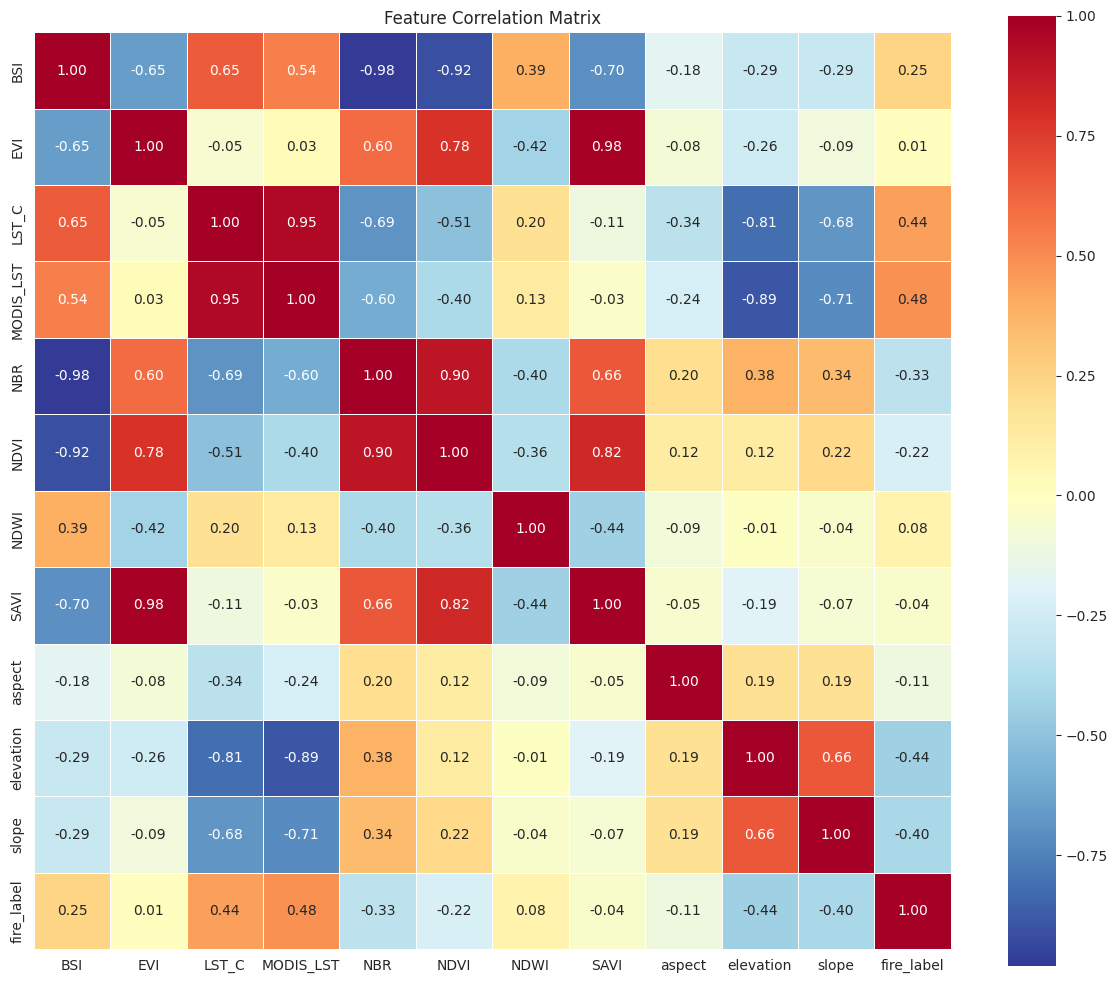


Correlation with fire_label
fire_label    1.000000
MODIS_LST     0.482663
LST_C         0.439270
BSI           0.247456
NDWI          0.077024
EVI           0.007628
SAVI         -0.043148
aspect       -0.111709
NDVI         -0.223443
NBR          -0.334517
slope        -0.402766
elevation    -0.441107
Name: fire_label, dtype: float64


In [11]:
# Group analysis according to fire label
print("Fire Label Distribution")
print(train_df["fire_label"].value_counts())
print(f"\nFire ratio: {train_df['fire_label'].mean():.2f}")

# Average of each attribute according to fire_labelı
print("\nMean values by fire_label")
print(train_df.groupby("fire_label")[numerical_var].mean().T)

# Corelation matrix
plt.figure(figsize=(12, 10))
correlation_features = numerical_var + ['fire_label'] # Include 'fire_label' for correlation
corr = train_df[correlation_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r",
            center=0, square=True, linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(f'{data_dir}/correlation_matrix.png', dpi=150)
plt.show()

print("\nCorrelation with fire_label")
print(corr["fire_label"].sort_values(ascending=False))

Outlier Detection (IQR)
BSI: 0 outlier (lower=-0.20, upper=0.21)
EVI: 15 outlier (lower=0.14, upper=0.39)
LST_C: 0 outlier (lower=16.47, upper=43.17)
MODIS_LST: 0 outlier (lower=13.73, upper=40.78)
NBR: 0 outlier (lower=-0.07, upper=0.59)
NDVI: 0 outlier (lower=0.17, upper=0.74)
NDWI: 6 outlier (lower=-0.69, upper=-0.29)
SAVI: 9 outlier (lower=0.15, upper=0.38)
aspect: 0 outlier (lower=-54.94, upper=426.16)
elevation: 12 outlier (lower=-874.25, upper=1799.75)
slope: 10 outlier (lower=-9.38, upper=18.05)

Total outlier counts: 30


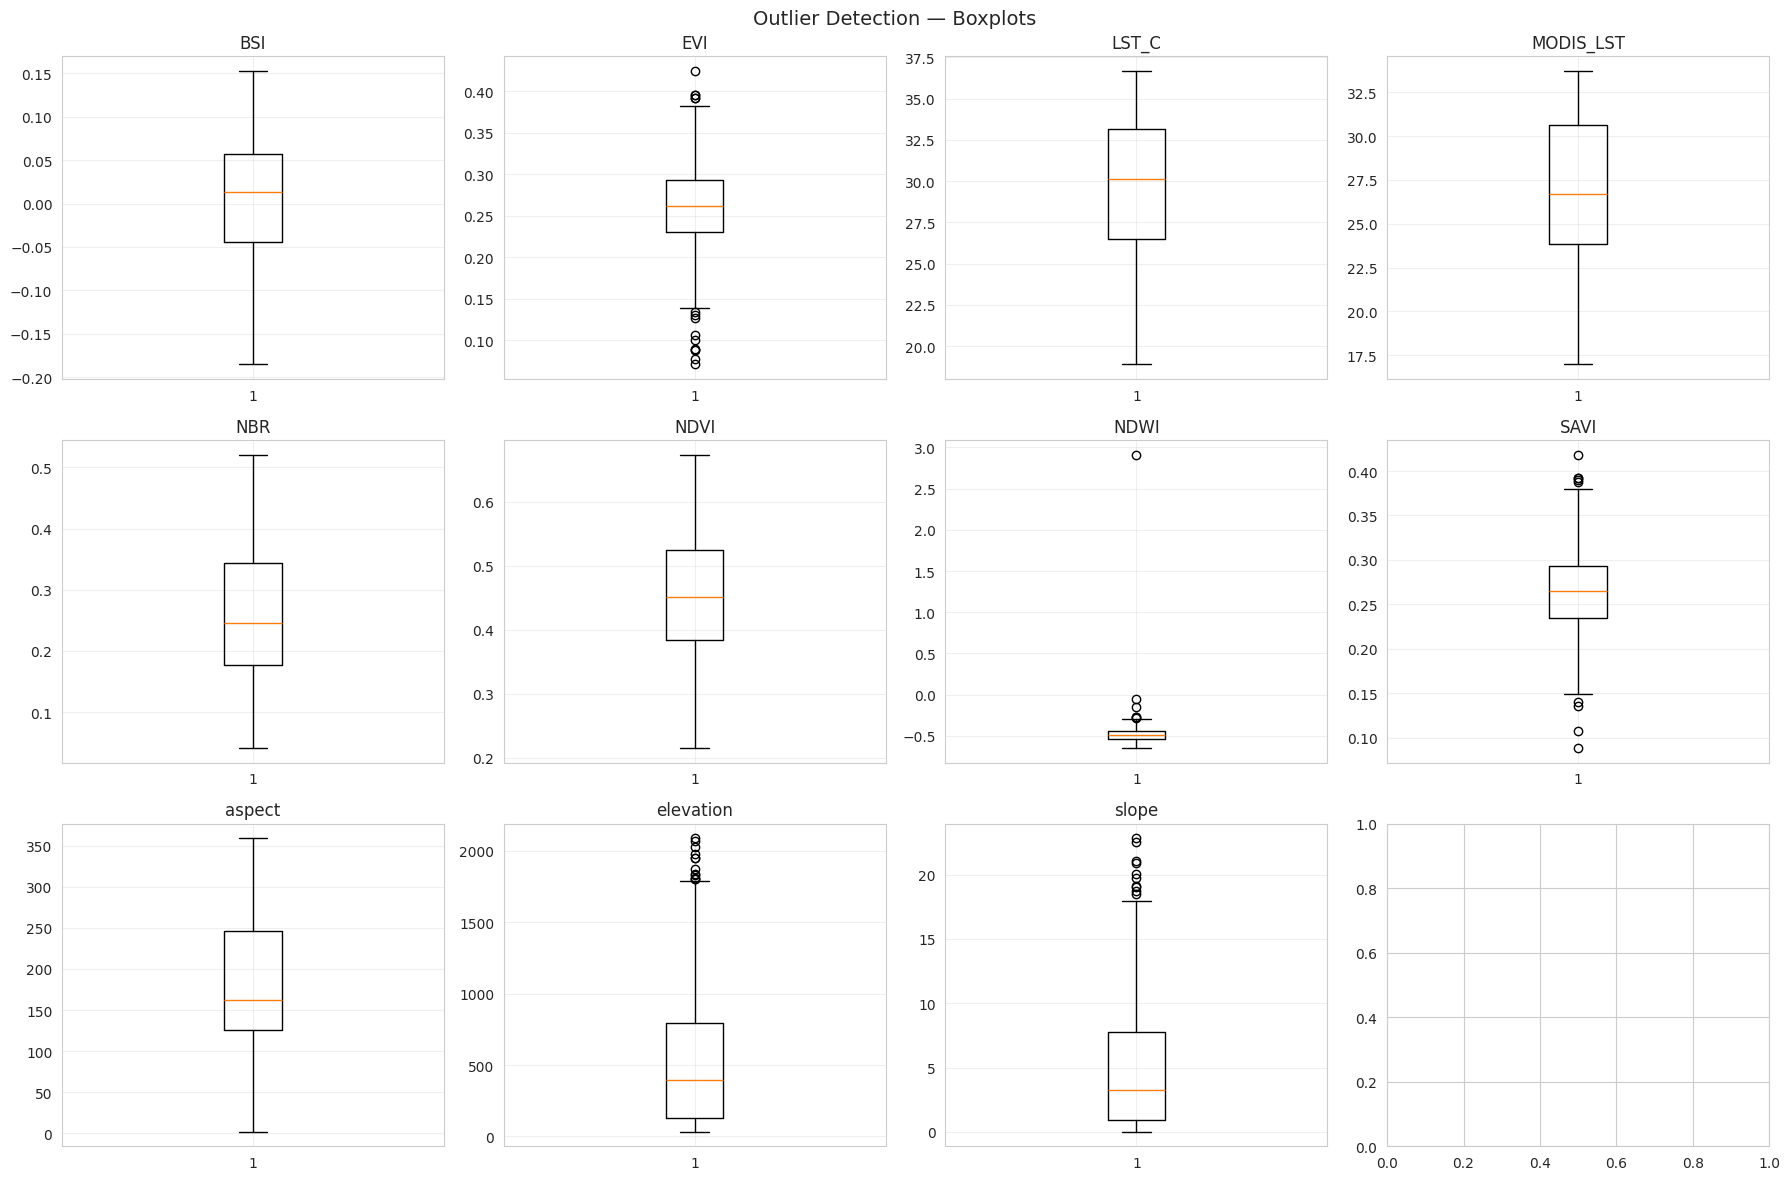


Original: 607 → Cleaned up: 577


In [12]:
# Outlier detection with IQR method
def detect_outliers(df, features):
    outlier_indices = []
    for col in features:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outliers = df[(df[col] < lower) | (df[col] > upper)].index
        outlier_indices.extend(outliers)
        print(f"{col}: {len(outliers)} outlier "
              f"(lower={lower:.2f}, upper={upper:.2f})")
    return list(Counter(outlier_indices).keys())

feature_cols = ["BSI", "EVI", "LST_C", "MODIS_LST", "NBR",
                "NDVI", "NDWI", "SAVI", "aspect", "elevation", "slope"]

print("Outlier Detection (IQR)")
outlier_idx = detect_outliers(train_df, feature_cols)
print(f"\nTotal outlier counts: {len(outlier_idx)}")

# Visualization with box plot
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for i, col in enumerate(feature_cols):
    axes[i].boxplot(train_df[col].dropna())
    axes[i].set_title(col)
    axes[i].grid(True, alpha=0.3)
plt.suptitle("Outlier Detection — Boxplots", fontsize=14)
plt.tight_layout()
plt.savefig(f'{data_dir}/outlier_boxplots.png', dpi=150)
plt.show()

# Clean up outliers
train_df_clean = train_df.drop(outlier_idx).reset_index(drop=True)
print(f"\nOriginal: {len(train_df)} → Cleaned up: {len(train_df_clean)}")

In [13]:
# Missing Value analysis
print("Missing Values")
missing = train_df_clean.isnull().sum()
missing_pct = (missing / len(train_df_clean)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)
print(missing_df[missing_df['Missing Count'] > 0])

# Fillng missing values with median
for col in feature_cols:
    if train_df_clean[col].isnull().sum() > 0:
        median_val = train_df_clean[col].median()
        train_df_clean[col].fillna(median_val, inplace=True)
        print(f"{col}: filled with {median_val:.2f} ")

print("\nNumber of missing values")
print(train_df_clean.isnull().sum().sum())

Missing Values
        Missing Count  Missing %
aspect             10   1.733102
slope              10   1.733102
aspect: filled with 160.64 
slope: filled with 3.18 

Number of missing values
0


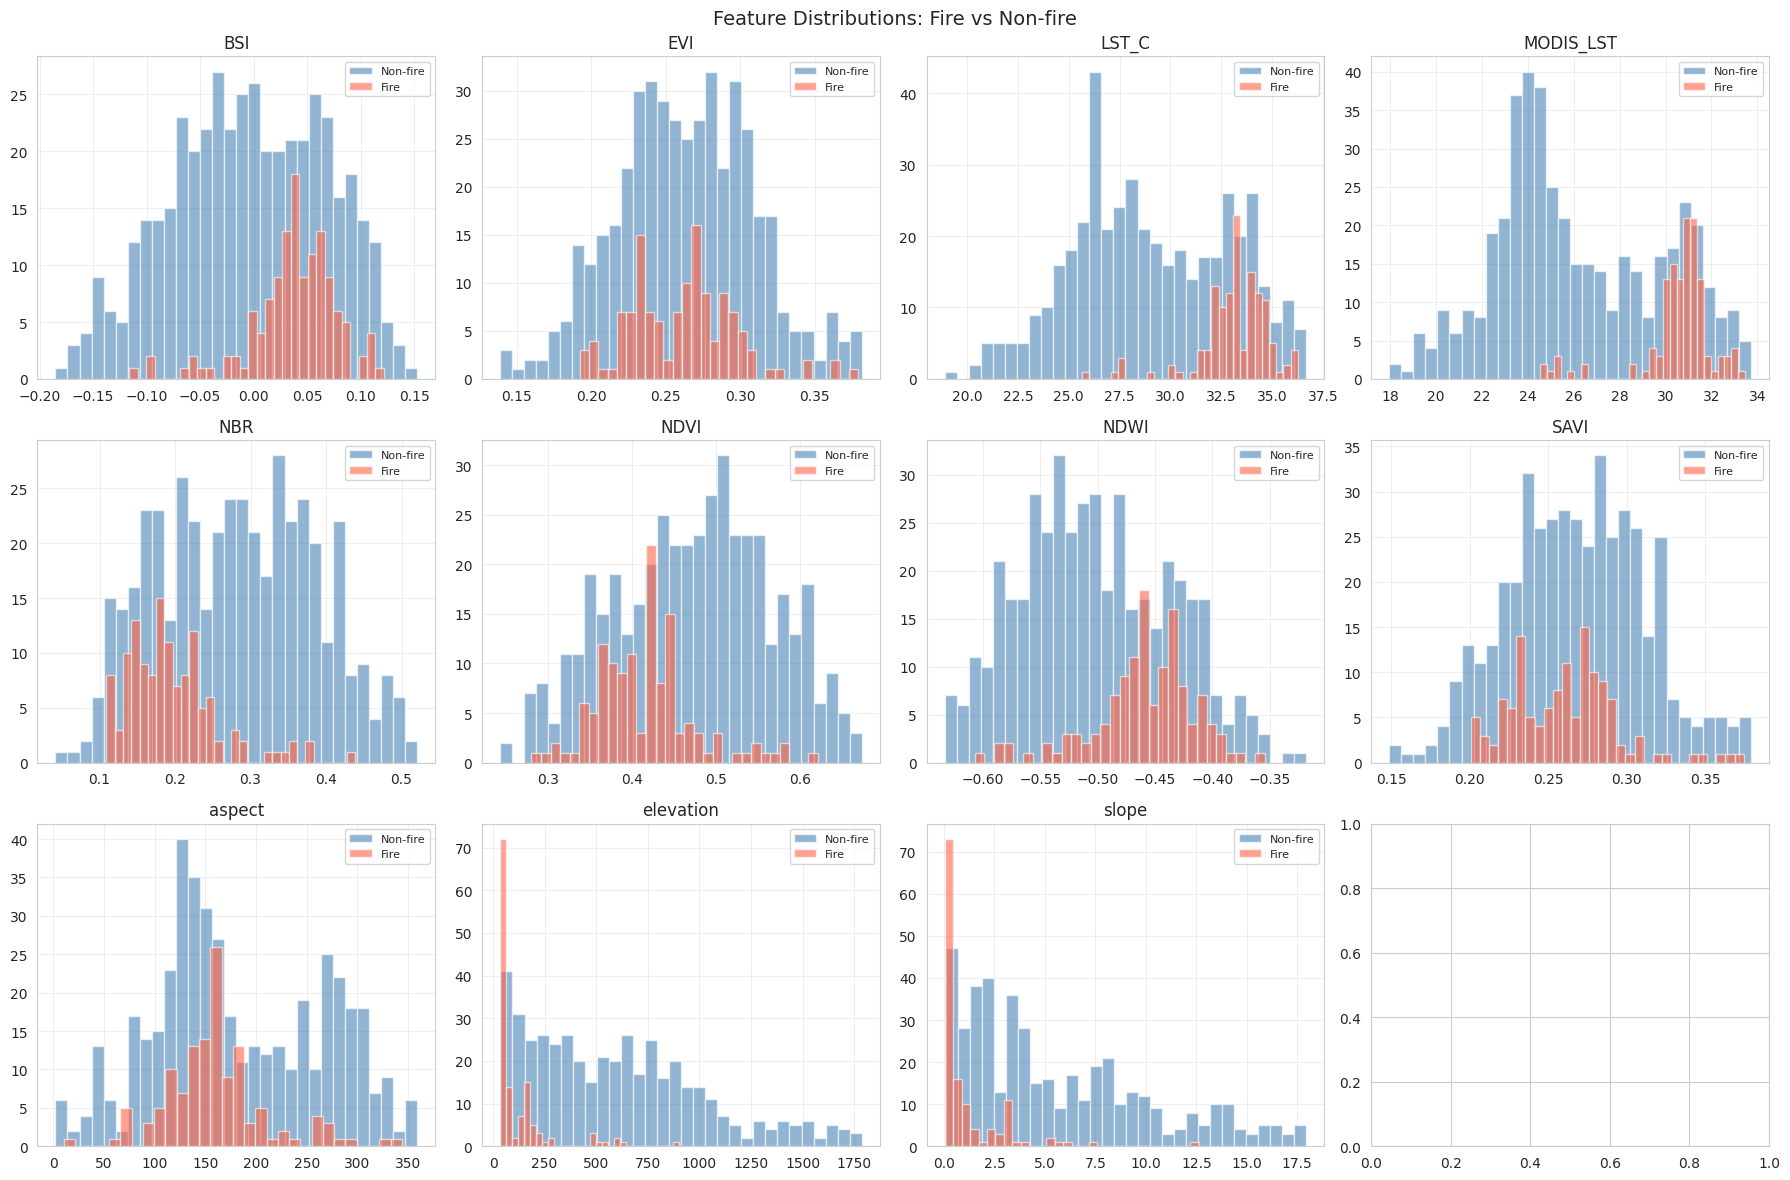

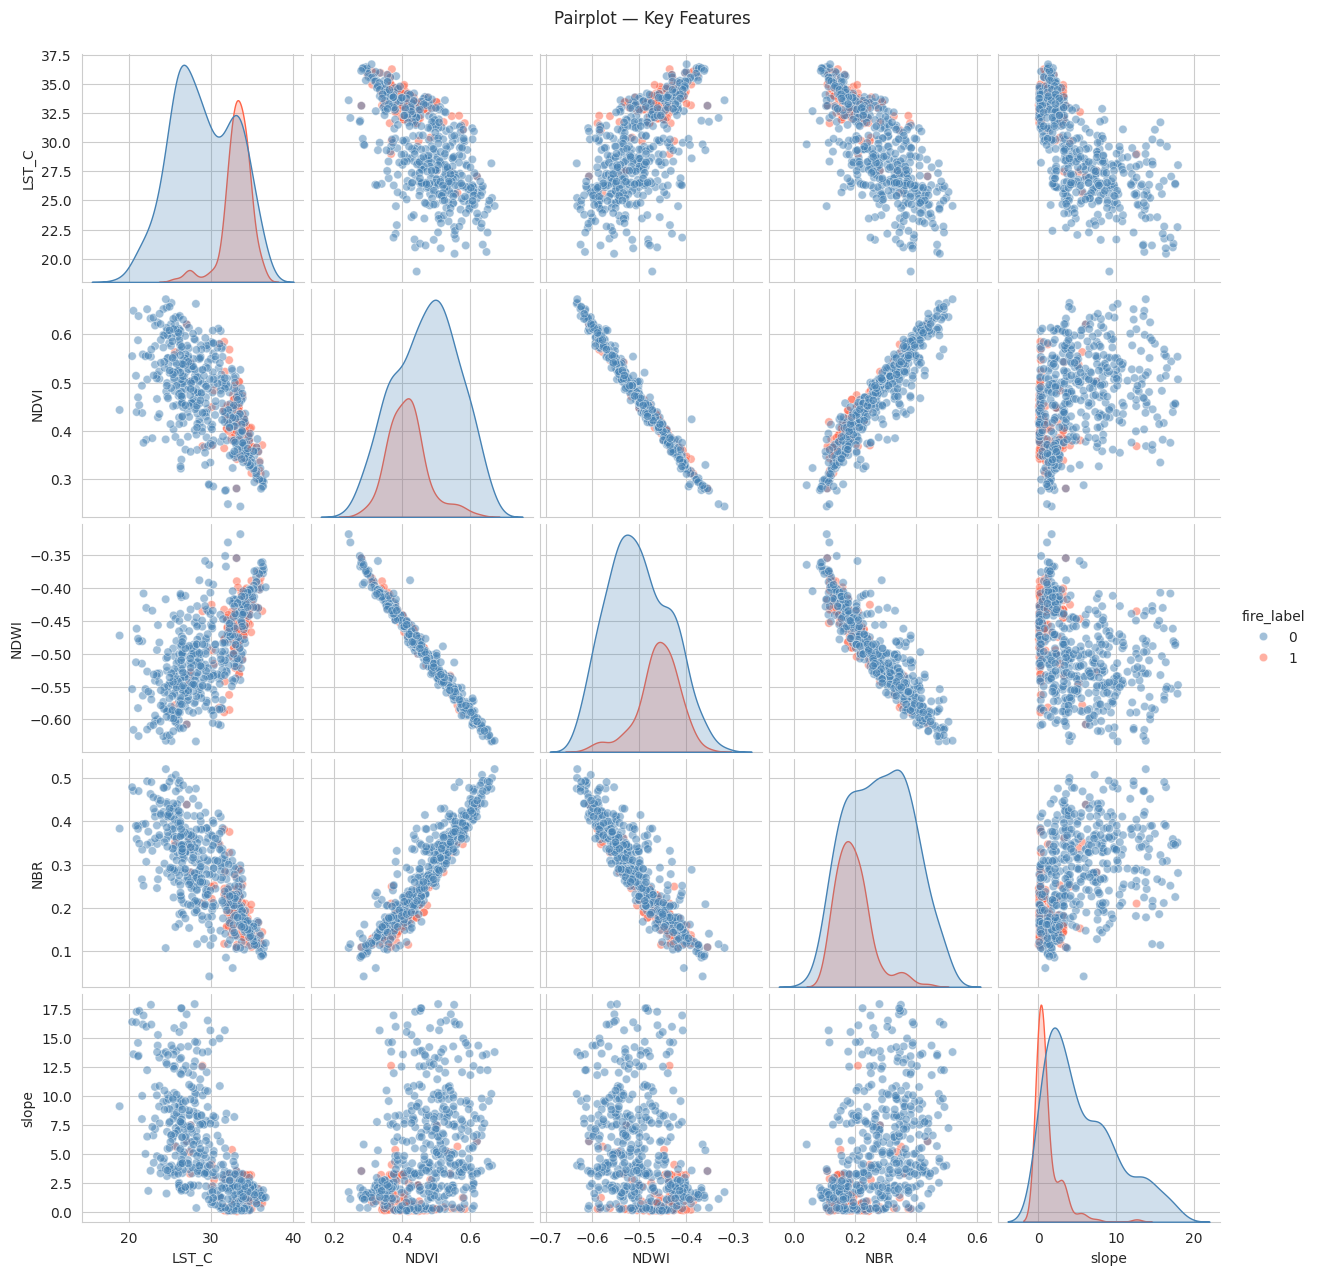

In [14]:
# Fire vs Non-fire
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(train_df_clean[train_df_clean['fire_label']==0][col],
                 bins=30, alpha=0.6, color='steelblue', label='Non-fire')
    axes[i].hist(train_df_clean[train_df_clean['fire_label']==1][col],
                 bins=30, alpha=0.6, color='tomato', label='Fire')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Feature Distributions: Fire vs Non-fire", fontsize=14)
plt.tight_layout()
plt.savefig(f'{data_dir}/feature_distributions.png', dpi=150)
plt.show()

# Pairplot
key_features = ['LST_C', 'NDVI', 'NDWI', 'NBR', 'slope', 'fire_label']
sns.pairplot(train_df_clean[key_features], hue='fire_label',
             palette={0: 'steelblue', 1: 'tomato'}, plot_kws={'alpha': 0.5})
plt.suptitle("Pairplot — Key Features", y=1.02)
plt.savefig(f'{data_dir}/pairplot.png', dpi=150)
plt.show()

In [15]:
# Feature engineering
train_df_clean['LST_NDVI_ratio'] = train_df_clean['LST_C'] / (train_df_clean['NDVI'] + 1e-6)
train_df_clean['fire_weather_index'] = (train_df_clean['LST_C'] *
                                         (1 - train_df_clean['NDWI']) *
                                         train_df_clean['slope'])
train_df_clean['dryness'] = train_df_clean['BSI'] - train_df_clean['NDWI']
train_df_clean['LST_diff'] = train_df_clean['LST_C'] - train_df_clean['MODIS_LST']

print("New features are added:")
print(train_df_clean[['LST_NDVI_ratio', 'fire_weather_index',
                        'dryness', 'LST_diff']].describe())

New features are added:
       LST_NDVI_ratio  fire_weather_index     dryness    LST_diff
count      577.000000          577.000000  577.000000  577.000000
mean        68.965114          189.556856    0.496967    2.823450
std         21.020049          176.673797    0.026394    1.216118
min         31.716469            1.398057    0.372237   -1.534435
25%         51.841636           44.587922    0.485113    2.123937
50%         66.263443          141.602894    0.500718    2.704968
75%         81.968906          299.007136    0.512638    3.531703
max        138.058258          778.708494    0.557662    6.913773


Train: 461 — Test: 116
SMOTE sonrası: 714, Fire ratio: 0.50

── Logistic Regression ──
              precision    recall  f1-score   support

    Non-fire       0.96      0.81      0.88        90
        Fire       0.57      0.88      0.70        26

    accuracy                           0.83       116
   macro avg       0.77      0.85      0.79       116
weighted avg       0.87      0.83      0.84       116


RF Best params: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 100}

── Random Forest (Grid Search) ──
              precision    recall  f1-score   support

    Non-fire       0.96      0.89      0.92        90
        Fire       0.70      0.88      0.78        26

    accuracy                           0.89       116
   macro avg       0.83      0.89      0.85       116
weighted avg       0.90      0.89      0.89       116

ROC-AUC: 0.9068

── Gradient Boosting ──
              precision    recall  f1-score   support

    Non-fire       0.94      0.88      0.91      

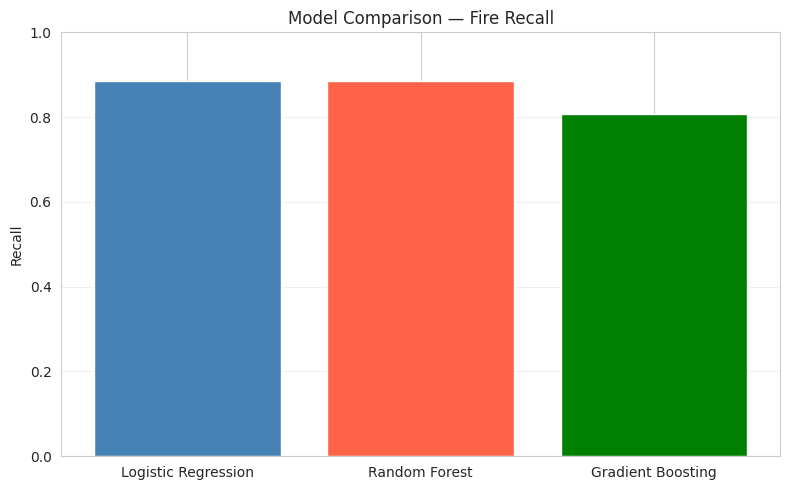


Model saved.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve, auc, recall_score)
from imblearn.over_sampling import SMOTE

# Final list of features
final_features = ['LST_C', 'MODIS_LST', 'NDVI', 'NDWI', 'NBR', 'EVI',
                  'SAVI', 'BSI', 'elevation', 'slope', 'aspect',
                  'LST_NDVI_ratio', 'fire_weather_index', 'dryness', 'LST_diff']

X = train_df_clean[final_features].values
y = train_df_clean['fire_label'].values

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {len(X_train)} — Test: {len(X_test)}")

# SMOTE
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"SMOTE sonrası: {len(X_train_sm)}, Fire ratio: {y_train_sm.mean():.2f}")

# 1. Logistic Regression (baseline)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr.fit(X_train_sm, y_train_sm)
y_pred_lr = lr.predict(X_test)
print("\n── Logistic Regression ──")
print(classification_report(y_test, y_pred_lr,
      target_names=['Non-fire', 'Fire'], zero_division=0))

# 2. Random Forest + Grid Search
rf_params = {
    'n_estimators': [100, 300],
    'max_depth': [10, 15, None],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_params, cv=5, scoring='recall', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train_sm, y_train_sm)
print(f"\nRF Best params: {rf_grid.best_params_}")

best_rf = rf_grid.best_estimator_
y_pred_rf    = best_rf.predict(X_test)
y_proba_rf   = best_rf.predict_proba(X_test)[:, 1]

print("\n── Random Forest (Grid Search) ──")
print(classification_report(y_test, y_pred_rf,
      target_names=['Non-fire', 'Fire'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")

# 3. Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=5,
    learning_rate=0.05, random_state=42
)
gb.fit(X_train_sm, y_train_sm)
y_pred_gb  = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("\n── Gradient Boosting ──")
print(classification_report(y_test, y_pred_gb,
      target_names=['Non-fire', 'Fire'], zero_division=0))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_gb):.4f}")

# Model Comparison
models = ['Logistic Regression', 'Random Forest', 'Gradient Boosting']
recalls = [
    recall_score(y_test, y_pred_lr, zero_division=0),
    recall_score(y_test, y_pred_rf, zero_division=0),
    recall_score(y_test, y_pred_gb, zero_division=0)
]

plt.figure(figsize=(8, 5))
plt.bar(models, recalls, color=['steelblue', 'tomato', 'green'])
plt.title('Model Comparison — Fire Recall')
plt.ylabel('Recall')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(f'{data_dir}/model_comparison.png', dpi=150)
plt.show()

# Save the best model
import joblib
joblib.dump(best_rf, f'{data_dir}/fire_risk_rf_final.pkl')
joblib.dump(scaler, f'{data_dir}/scaler_final.pkl')
print('\nModel saved.')

Epoch 30/150 — Loss: 0.4856
Epoch 60/150 — Loss: 0.4629
Epoch 90/150 — Loss: 0.4207
Epoch 120/150 — Loss: 0.3893
Epoch 150/150 — Loss: 0.3724

MLP Threshold Optimization
Threshold Precision    Recall     F1
----------------------------------------
0.20     0.444        0.923     0.600
0.25     0.444        0.923     0.600
0.30     0.444        0.923     0.600
0.35     0.453        0.923     0.608
0.40     0.453        0.923     0.608
0.45     0.471        0.923     0.623
0.50     0.480        0.923     0.632
0.55     0.500        0.923     0.649

Best threshold: 0.55

MLP Final Results
              precision    recall  f1-score   support

    Non-fire       0.97      0.73      0.84        90
        Fire       0.50      0.92      0.65        26

    accuracy                           0.78       116
   macro avg       0.74      0.83      0.74       116
weighted avg       0.87      0.78      0.79       116

ROC-AUC: 0.9077
PR-AUC:  0.7048


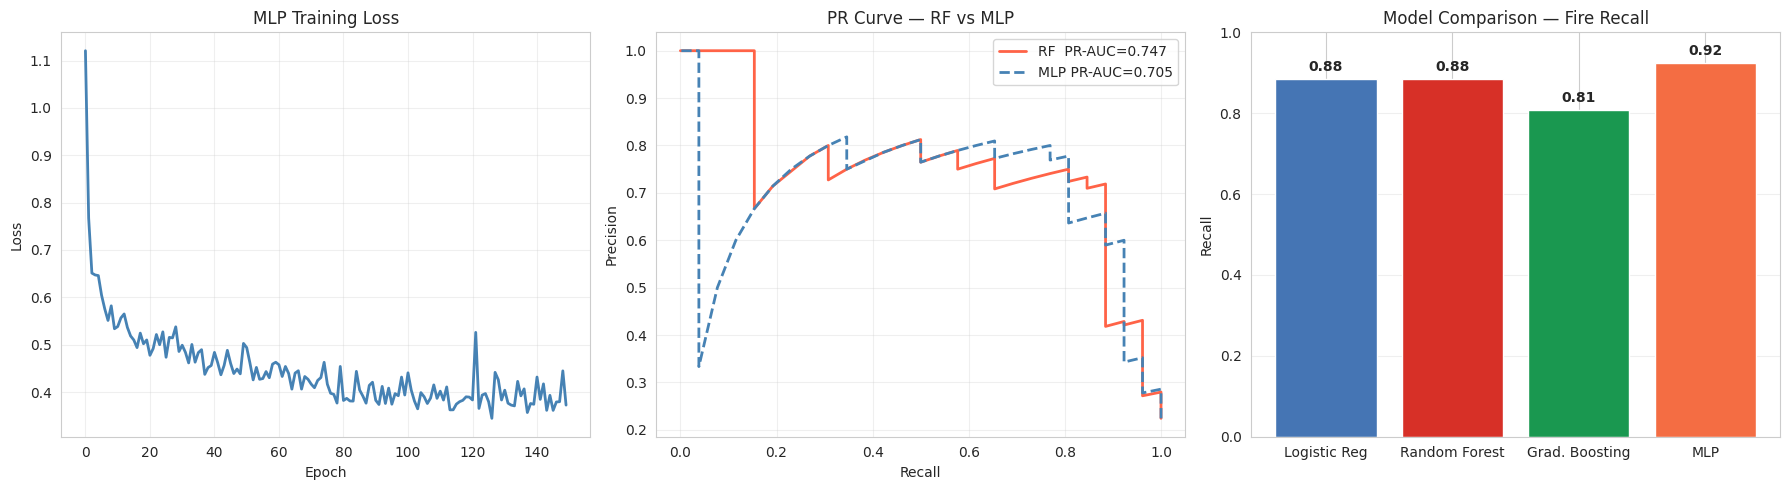

MLP model saved.


In [18]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import recall_score, precision_score, f1_score

# Trasnform to Tensor
X_train_t = torch.FloatTensor(X_train_sm)
y_train_t = torch.FloatTensor(y_train_sm)
X_test_t  = torch.FloatTensor(X_test)

# MLP Structure
class FireRiskMLP(nn.Module):
    def __init__(self, input_dim):
        super(FireRiskMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x).squeeze()

# DataLoader
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Model, Loss, Optimizer
input_dim  = X_train_sm.shape[1]
model      = FireRiskMLP(input_dim=input_dim)
pos_weight = torch.tensor([3.0])  # fire sınıfına ağırlık
criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=10, factor=0.5)

# Train
epochs       = 150
train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss   = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    scheduler.step(avg_loss)
    if (epoch+1) % 30 == 0:
        print(f'Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f}')

# Evaluation
model.eval()
with torch.no_grad():
    logits        = model(X_test_t)
    y_proba_mlp   = torch.sigmoid(logits).numpy()

# Threshold optimization
print('\nMLP Threshold Optimization')
print(f'{"Threshold":<8} {"Precision":<12} {"Recall":<10} {"F1"}')
print('-' * 40)

best_t   = 0.5
best_f1  = 0

for t in np.arange(0.2, 0.6, 0.05):
    y_pred_t = (y_proba_mlp >= t).astype(int)
    p = precision_score(y_test, y_pred_t, zero_division=0)
    r = recall_score(y_test, y_pred_t, zero_division=0)
    f = f1_score(y_test, y_pred_t, zero_division=0)
    print(f'{t:.2f}     {p:.3f}        {r:.3f}     {f:.3f}')
    if f > best_f1:
        best_f1 = f
        best_t  = t

y_pred_mlp = (y_proba_mlp >= best_t).astype(int)

print(f'\nBest threshold: {best_t:.2f}')
print('\nMLP Final Results')
print(classification_report(y_test, y_pred_mlp,
      target_names=['Non-fire', 'Fire'], zero_division=0))

roc_auc_mlp = roc_auc_score(y_test, y_proba_mlp)
pr_p, pr_r, _ = precision_recall_curve(y_test, y_proba_mlp)
pr_auc_mlp    = auc(pr_r, pr_p)
print(f'ROC-AUC: {roc_auc_mlp:.4f}')
print(f'PR-AUC:  {pr_auc_mlp:.4f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training loss
axes[0].plot(train_losses, color='steelblue', linewidth=2)
axes[0].set_title('MLP Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].grid(True, alpha=0.3)

# PR Curve comparison
pr_p_rf, pr_r_rf, _ = precision_recall_curve(y_test, y_proba_rf)
axes[1].plot(pr_r_rf,  pr_p_rf,  color='tomato',    linewidth=2,
             label=f'RF  PR-AUC={auc(pr_r_rf, pr_p_rf):.3f}')
axes[1].plot(pr_r, pr_p, color='steelblue', linewidth=2, linestyle='--',
             label=f'MLP PR-AUC={pr_auc_mlp:.3f}')
axes[1].set_title('PR Curve — RF vs MLP')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Model comparison
models  = ['Logistic Reg', 'Random Forest', 'Grad. Boosting', 'MLP']
recalls = [
    recall_score(y_test, y_pred_lr,  zero_division=0),
    recall_score(y_test, y_pred_rf,  zero_division=0),
    recall_score(y_test, y_pred_gb,  zero_division=0),
    recall_score(y_test, y_pred_mlp, zero_division=0)
]
colors = ['#4575b4', '#d73027', '#1a9850', '#f46d43']
axes[2].bar(models, recalls, color=colors)
axes[2].set_title('Model Comparison — Fire Recall')
axes[2].set_ylabel('Recall')
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(recalls):
    axes[2].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{data_dir}/model_comparison_all.png', dpi=150)
plt.show()

# Save model
torch.save(model.state_dict(), f'{data_dir}/fire_risk_mlp.pt')
print('MLP model saved.')